# **Naive Bayes Classification Challenge: End-to-End AI Pipeline**  
*From Data Cleaning to Model Comparison*  

In this hands-on challenge, **YOU** will go through a complete **AI/ML pipeline** using **Naive Bayes** classification. The dataset will have:  
✅ **Missing values** (requiring imputation)  
✅ **Categorical features** (requiring encoding)  
✅ **Text data** (if applicable, requiring TF-IDF/BOW)  
✅ **Numerical features** (for Gaussian Naive Bayes)  

---

## **Pipeline Steps**  
1. **Data Loading & Exploration**  
2. **Handling Missing Values**  
3. **Encoding Categorical Features**  
5. **Train-Test Split**  
6. **Naive Bayes from Scratch**  
7. **Naive Bayes using `scikit-learn`**  
8. **Model Comparison & Analysis**  

---

### **Learning Objectives**  
- Practice full ML workflow from raw data to evaluation  
- Compare manual vs. library implementations  
- Understand the impact of preprocessing decisions  

Let's begin!

# 🛳️ Titanic Dataset Overview

The Titanic dataset is a classic benchmark in machine learning, especially for classification problems. It contains data about the passengers on the Titanic, and the task is to predict whether a passenger survived or not based on features like age, sex, ticket class, etc.

### 📌 Why This Dataset?
- It includes **numerical**, **categorical**, and **text** features, making it perfect for practicing data preprocessing.
- The target variable is **binary** (0 = Died, 1 = Survived), making it ideal for binary classification algorithms like Naive Bayes.
- It has **missing values**, which allows us to practice imputation.

### 🎯 Target Column
- `Survived`: This is the column we are trying to predict.
    - `0` = Passenger did not survive
    - `1` = Passenger survived

### 📊 Key Features
- `Pclass`: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- `Sex`: Gender of the passenger
- `Age`: Age in years
- `SibSp`: Number of siblings/spouses aboard
- `Parch`: Number of parents/children aboard
- `Fare`: Fare paid for the ticket
- `Embarked`: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
- `Cabin`, `Name`, `Ticket`: Not typically useful without heavy preprocessing

# **Step 1: Data Loading & Exploration**

# Import essential libraries and load the dataset. Perform initial inspection.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Display all columns when printing the DataFrame
# pd.set_option('display.max_columns', None)

# Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)

# Show the first 5 records to understand the structure
print("First 5 rows of the dataset:")
display(data.head())


First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
len(data)

891

# **Step 2: Initial Data Exploration**

## Explore datatypes, nulls, and summary statistics.

In [7]:
# Explore datatypes, nulls, and summary statistics.

print("\nDataset Info:")
data.info()

print("\nSummary of Numerical Columns:")
display(data.describe())

print("\nMissing Values Per Column:")
print(data.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Summary of Numerical Columns:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values Per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Visualize the target distribution

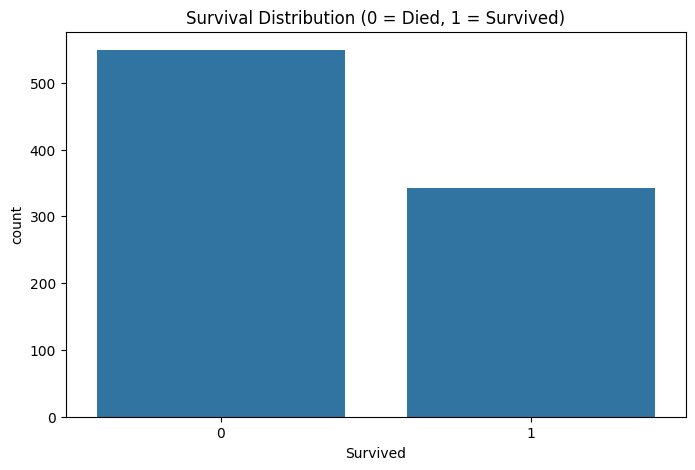

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=data)
plt.title("Survival Distribution (0 = Died, 1 = Survived)")
plt.show()


## Visualize survival by gender

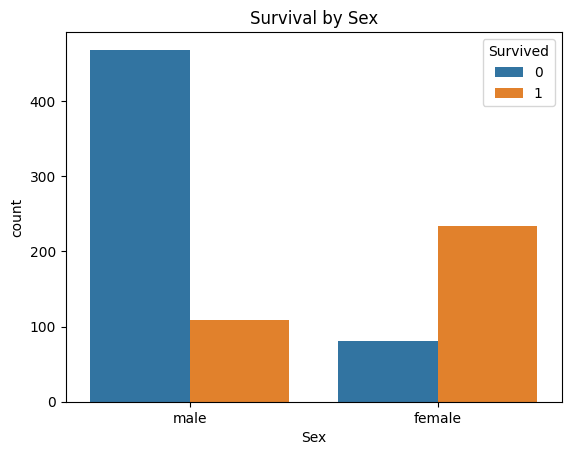

In [9]:
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Survival by Sex")
plt.show()

## Age distribution by survival

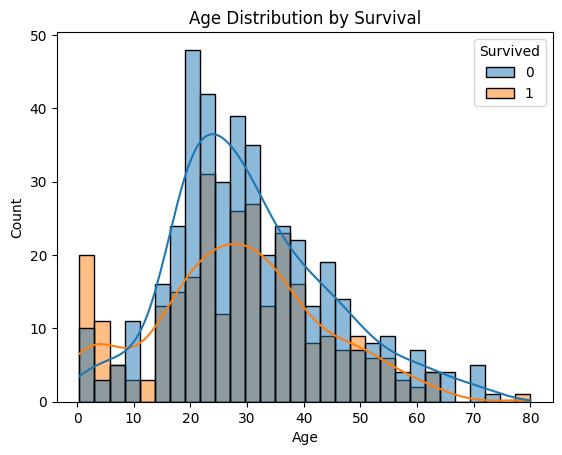

In [10]:
sns.histplot(data=data, x='Age', hue='Survived', kde=True, bins=30)
plt.title("Age Distribution by Survival")
plt.show()

#**Step 3: Handling Missing Values**

# Impute missing numerical and categorical values appropriately.


In [11]:
from sklearn.impute import SimpleImputer

# Impute Age with median

In [12]:
age_imputer = SimpleImputer(strategy='median')
data['Age'] = age_imputer.fit_transform(data[['Age']])

# Impute Embarked with most frequent value

In [13]:
data['Embarked'] = SimpleImputer(strategy='most_frequent').fit_transform(data[['Embarked']]).ravel()

# Drop Cabin (too sparse)

In [14]:
data.drop(columns=['Cabin'], inplace=True)


# Confirm missing values handled


In [15]:
print("\nRemaining Missing Values:")
print(data.isnull().sum())


Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#**Step 4: Encoding Categorical Features**

# Encode 'Sex' and 'Embarked' using Label Encoding.

In [16]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
le_embarked = LabelEncoder()

data['Sex'] = le_sex.fit_transform(data['Sex'])
data['Embarked'] = le_embarked.fit_transform(data['Embarked'])

In [17]:
data['Embarked']

0      2
1      0
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    0
890    1
Name: Embarked, Length: 891, dtype: int32

# Drop irrelevant features


In [18]:
data['PassengerId'].nunique() == len(data)

True

In [19]:
data['Ticket'].nunique()

681

In [20]:
data.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print("\nData After Preprocessing:")
display(data.head())



Data After Preprocessing:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


# 📚 Introduction to Naive Bayes Classifier

## 🧠 What is Naive Bayes?

Naive Bayes is a **supervised machine learning algorithm** based on **Bayes' Theorem**, primarily used for **classification** tasks.

It’s called **“naive”** because it assumes that all features (input variables) are **independent of each other**, which is rarely true in real-world data — but this simplification works surprisingly well in practice!

---

### 📐 Bayes’ Theorem
P(Y | X) = (P(X | Y) * P(Y)) / P(X)

Where:
- P(Y | X): Posterior → Probability of class Y given data X
- P(X | Y): Likelihood → Probability of observing data X given class Y
- P(Y): Prior → Overall probability of class Y
- P(X): Evidence → Overall probability of data X (same for all classes, often ignored)


---

### 🧪 Intuition Through Example

Let’s say we’re predicting whether a passenger on the Titanic survived (`Survived = 1`) or not (`Survived = 0`) based on `Age` and `Fare`.

Suppose we compute:
- \( P(Survived = 1) = 0.4 \), \( P(Survived = 0) = 0.6 \)
- For a person with Age = 25 and Fare = 80:
  - \( P(Age=25 | Survived=1) = 0.03 \)
  - \( P(Fare=80 | Survived=1) = 0.04 \)
  - Posterior (Survived=1) ∝ 0.4 × 0.03 × 0.04

We do this for each class and pick the class with the **higher probability**.

---

## 🔄 Types of Naive Bayes

| Type            | Feature Type         | Use Case Example                        |
|-----------------|----------------------|------------------------------------------|
| **GaussianNB**  | Continuous           | Age, Salary, Height (numerical)         |
| **MultinomialNB** | Discrete counts     | Word counts in text, bag-of-words model |
| **BernoulliNB** | Binary (0/1)         | Spam detection (word present or not)    |
| **CategoricalNB** | Categorical values  | Survey data, multiple-choice options    |
| **ComplementNB** | Text with imbalance | Sentiment analysis with skewed labels   |

---

## 📊 What Are We Doing?

In this project, we’ll implement and compare two versions of **Gaussian Naive Bayes**:

1. **From Scratch** (manual math & code)
2. **Using `sklearn`'s GaussianNB** (library version)

---

## 🧮 What is Gaussian Naive Bayes?

Gaussian Naive Bayes assumes that the features follow a **normal (Gaussian) distribution**.

### Probability Density Function:

P(xᵢ | y) = (1 / sqrt(2 * π * σ²)) * e ^ [ - (xᵢ - μ)² / (2 * σ²) ]

Where:
- P(xᵢ | y): Likelihood of feature xᵢ given class y
- μ (mu): Mean of the feature for class y
- σ² (sigma squared): Variance of the feature for class y
- e: Euler’s number (≈ 2.718), the base of natural logarithms

### Why Gaussian?

It is especially useful when:
- Input features are **continuous**
- Distribution of values is **bell-shaped** (like Age, Fare, etc.)

---

### ✅ Advantages of Naive Bayes

- Very **fast** and **simple** to implement
- Performs well with **small datasets**
- Works great with **high-dimensional data** (like text)

---

### ⚠️ Limitations

- Assumes **independence** between features (not always realistic)
- GaussianNB is **sensitive to outliers** (since it uses mean and variance)

---

For moe info you can read from this tutorial as well: https://www.geeksforgeeks.org/machine-learning/gaussian-naive-bayes/


# **Step 5: Train-Test Split**

# Split the dataset into training and testing sets.

In [21]:
from sklearn.model_selection import train_test_split

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")




Training Samples: 712
Testing Samples: 179


#**Step 6: Naive Bayes from Scratch**

In [28]:
import math
import numpy as np

class GaussianNB_Scratch:
    """
    A custom implementation of Gaussian Naive Bayes classifier.
    Assumes features follow a Gaussian (normal) distribution.
    """

    def fit(self, X, y):
        """
        Train the model by computing class-specific statistics:
        - mean and variance for each feature
        - prior probability for each class
        """
        self.classes = np.unique(y)  # Get unique class labels (e.g., 0 and 1)
        self.mean = {}   # To store feature-wise mean for each class
        self.var = {}    # To store feature-wise variance for each class
        self.priors = {} # To store prior probabilities of each class
# 0 and 1
        for cls in self.classes:
            # Subset the training data for this class
            X_cls = X[y == cls]

            # Calculate mean and variance for each feature for this class
            self.mean[cls] = X_cls.mean()
            self.var[cls] = X_cls.var() + 1e-6  # Add small value to prevent division by zero

            # Calculate prior: P(class) = (# samples in class) / (total samples)
            self.priors[cls] = len(X_cls) / len(X)

    def _log_likelihood(self, x, mean, var):
        """
        Compute the log of Gaussian probability density function:
        log(P(x|y)) for continuous features assuming Gaussian distribution.
        """
        # Gaussian log-likelihood: sum over all features
        return -0.5 * np.sum(np.log(2 * np.pi * var)) - np.sum(((x - mean) ** 2) / (2 * var))

    def predict(self, X):
      """
      Predict the class label for each sample in X using the Naive Bayes formula.

      -----------------------------
      💡 Bayes’ Theorem (Original):
      -----------------------------
      P(y | X) = [ P(X | y) * P(y) ] / P(X)

      - P(y | X): Posterior — probability of class y given data X (what we want to compute)
      - P(X | y): Likelihood — how likely the features are under class y
      - P(y): Prior — how likely the class is overall (from training data)
      - P(X): Evidence — probability of data X (same for all classes, so ignored during comparison)

      -----------------------------
      🔄 But here's the problem:
      -----------------------------
      - P(X | y) is a product of many small probabilities, one per feature:
        P(x1 | y) * P(x2 | y) * ... * P(xn | y)
      - Multiplying many small numbers → can cause **numerical underflow** (values too close to 0)

      --------------------------------------------
      ✅ Solution: Use log of probabilities instead:
      --------------------------------------------
      - log(P(y | X)) ∝ log(P(y)) + log(P(x1 | y)) + ... + log(P(xn | y))
      - This turns multiplication into addition and avoids underflow.
      - Also faster and easier to implement.

      So in this function:
      → We compute log(P(y)) + sum of log(P(x_i | y)) for each class
      → Pick the class with the highest final score
      """

      results = []

      # Loop over each sample (row) in input X
      for _, x in X.iterrows():
          posteriors = {}  # To store log posterior probabilities for each class

          # Calculate log posterior for each class (0 and 1)
          for cls in self.classes:
              # Step 1: log(P(y)) — log of the prior probability of the class
              # Example: If P(Survived=1) = 0.38, log(P(y)) = log(0.38)
              prior = np.log(self.priors[cls])

              # Step 2: log(P(X | y)) — log likelihood of features given class
              # This assumes each feature is Gaussian-distributed and conditionally independent
              likelihood = self._log_likelihood(x, self.mean[cls], self.var[cls])

              # Step 3: log posterior = log prior + log likelihood
              # This gives us a score proportional to log(P(y | X))
              posteriors[cls] = prior + likelihood

          # Step 4: Choose class with the highest log posterior probability
          # For example: if log P(Survived=0) = -6.1 and log P(Survived=1) = -6.3 → predict 0
          predicted_class = max(posteriors, key=posteriors.get)
          results.append(predicted_class)

      # Return the predicted class labels for all samples as a NumPy array
      return np.array(results)



In [29]:
scratch_nb = GaussianNB_Scratch()
scratch_nb.fit(X_train, y_train)
y_pred_scratch = scratch_nb.predict(X_test)


#**Step 7: Naive Bayes using Scikit-Learn**

##Use GaussianNB with a standard pipeline.

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(StandardScaler(), GaussianNB())
model.fit(X_train, y_train)
y_pred_lib = model.predict(X_test)

#**Step 8: Model Comparison & Analysis**

#Compare accuracy, classification report, and confusion matrix.

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Evaluation function

In [32]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n🔍 Evaluation for: {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

##Compare both models


🔍 Evaluation for: Naive Bayes from Scratch
Accuracy: 0.7821229050279329

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



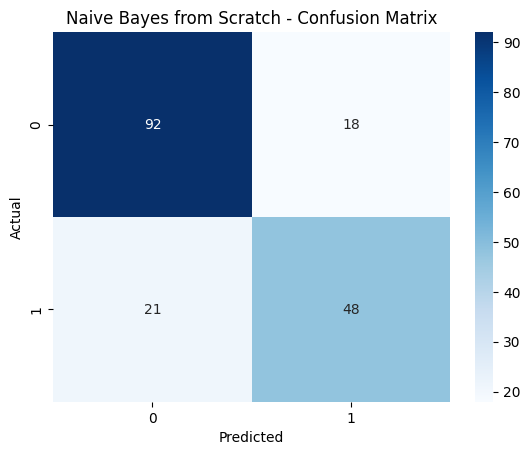

In [33]:
evaluate_model("Naive Bayes from Scratch", y_test, y_pred_scratch)


🔍 Evaluation for: Naive Bayes (Scikit-learn)
Accuracy: 0.7821229050279329

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



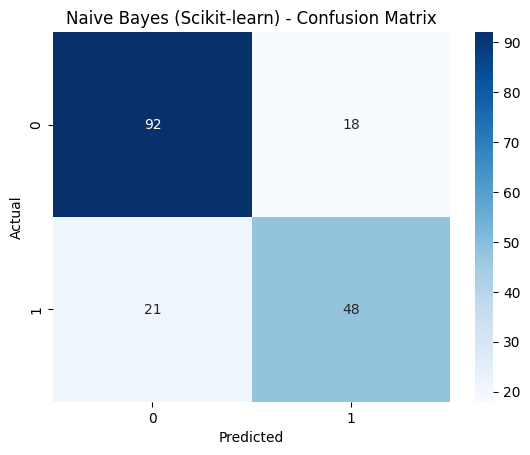

In [27]:
evaluate_model("Naive Bayes (Scikit-learn)", y_test, y_pred_lib)